## 1. Project Introduction

## 🎓 Student Performance Analysis

## 📖 Overview
This project aims to analyze the factors that influence student academic performance.  
By exploring various attributes such as study habits, socio-economic background, and lifestyle factors, we try to understand what contributes most to students' success.

## 🎯 Objective
The main objective is to:
- Analyze the relationship between different features and student performance.
- Identify key factors that affect exam scores.
- Build a predictive model to estimate student performance.

## 🎯 Target Variable
- **Exam_Score** → Represents the student's final exam score (continuous numerical value).

## 2. Dataset Description

The dataset contains multiple features related to students' academic behavior, personal habits, and socio-economic conditions.  
Each row represents a student, and each column represents a specific attribute.

## 📘3. Data Dictionary

| Column Name | Description |
|------------|------------|
| Hours_Studied | Number of hours a student studies per week. |
| Attendance | Percentage of classes attended by the student. |
| Parental_Involvement | Level of parents' involvement in the student's education (e.g., Low, Medium, High). |
| Access_to_Resources | Availability of learning resources (books, internet, etc.). |
| Extracurricular_Activities | Participation in activities outside academic studies (Yes/No). |
| Sleep_Hours | Average number of hours the student sleeps per day. |
| Previous_Scores | Student’s academic performance in previous exams. |
| Motivation_Level | Student's level of motivation (Low, Medium, High). |
| Internet_Access | Whether the student has access to the internet (Yes/No). |
| Tutoring_Sessions | Number of extra tutoring sessions attended. |
| Family_Income | Economic status of the student’s family (Low, Medium, High). |
| Teacher_Quality | Perceived quality of teaching (Low, Medium, High). |
| School_Type | Type of school (Public / Private). |
| Peer_Influence | Influence of friends on academic performance (Positive, Neutral, Negative). |
| Physical_Activity | Level of physical activity or exercise. |
| Learning_Disabilities | Whether the student has learning disabilities (Yes/No). |
| Parental_Education_Level | Highest education level of parents. |
| Distance_from_Home | Distance between home and school. |
| Gender | Gender of the student. |
| Exam_Score | Final exam score obtained by the student (Target Variable). |

## 📥 Data Loading

In this section, we import the necessary libraries and load the dataset into a pandas DataFrame.  
This allows us to explore and manipulate the data efficiently.

### 📚 Libraries Used
- **pandas** → For data manipulation and analysis  
- **numpy** → For numerical operations  
- **matplotlib** → For data visualization  
- **seaborn** → For advanced data visualization  
After loading the dataset, we display the first few rows to get an initial understanding of the data.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

# Display first 5 rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 🔍 Data Overview

In this section, we explore the basic structure of the dataset, including:
- The number of rows and columns
- Data types and missing values
- Statistical summary of numerical features

In [12]:
print("🔹 Dataset Shape:", df.shape)

print("\n🔹 Data Information:")
df.info()

print("\n🔹 Statistical Summary:")
display(df.describe())

🔹 Dataset Shape: (6607, 20)

🔹 Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13 

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## 🧹 Data Cleaning

### 🎯 Handling Invalid Values

While exploring the dataset, we noticed that some values in the **Exam_Score** column exceed 100, which is not realistic since exam scores typically range from 0 to 100.

To ensure data quality and maintain meaningful analysis, we remove any records where the exam score is greater than 100.

In [13]:
# Check how many invalid values exist
invalid_scores = df[df['Exam_Score'] > 100]
print("Number of invalid scores:", invalid_scores.shape[0])

# Remove invalid values
df = df[df['Exam_Score'] <= 100]

# Verify the cleaning
print("Max score after cleaning:", df['Exam_Score'].max())

Number of invalid scores: 1
Max score after cleaning: 100


## 🔍 Missing Values Analysis

Before proceeding with data analysis and modeling, it is important to check for missing values in the dataset.

Missing values can affect the accuracy of the analysis and the performance of machine learning models.  
In this step, we identify how many missing values exist in each column.

In [14]:
# Check missing values in each column
missing_values = df.isna().sum()

# Display only columns with missing values
missing_values[missing_values > 0]

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

## 🧹 Handling Missing Values

### 📌 Categorical Features

The following columns contain missing values:
- Teacher_Quality
- Parental_Education_Level
- Distance_from_Home

Since these are categorical variables, we handle missing values by replacing them with the **most frequent category (mode)**.

### 🎯 Why Mode?
- It preserves the distribution of the data  
- It is suitable for categorical variables  
- It minimizes distortion in the dataset  

In [15]:
# List of categorical columns with missing values
categorical_cols = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

# Fill missing values with mode
for col in categorical_cols:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

# Verify no missing values remain
df[categorical_cols].isna().sum()

C:\Users\tadoa\AppData\Local\Temp\ipykernel_16880\1517974860.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


Teacher_Quality             0
Parental_Education_Level    0
Distance_from_Home          0
dtype: int64

## 🧹 Checking for Duplicates

We check the dataset for duplicate rows to ensure data quality.  
Duplicate records can bias the analysis and model performance.  

After checking, we found **no duplicates**, so the dataset is clean in this regard.

In [16]:
# Check for duplicate rows
df.duplicated().sum()

0

## 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial step in understanding the dataset.  
It helps to:

- Gain insights into the distribution of each feature.
- Understand the relationships between features and the target variable (**Exam_Score**).
- Identify patterns, trends, and potential outliers.
- Guide decisions for feature engineering and modeling.

### 🔹 What we will explore
1. **Distribution of the target variable** – to understand how exam scores are spread.  
2. **Correlation among numerical features** – to identify which factors are most related to exam scores.  
3. **Relationships between numerical features and Exam_Score** – scatter plots with regression lines.  
4. **Categorical features vs Exam_Score** – boxplots to see how different categories impact scores.  
5. **Additional insights** – outliers, trends, and unusual patterns.

### 📈 Distribution of Exam Scores

We start by examining the distribution of the target variable, **Exam_Score**, to understand how students are performing overall.

- A histogram with a Kernel Density Estimate (KDE) shows the frequency of each score range.  
- From the graph, we can see that most exam scores are clustered between **60 and 70**, indicating that the dataset mostly contains mid-range scores.  
- Understanding this distribution helps in identifying whether the target is skewed or balanced, which is important for modeling and interpreting results.

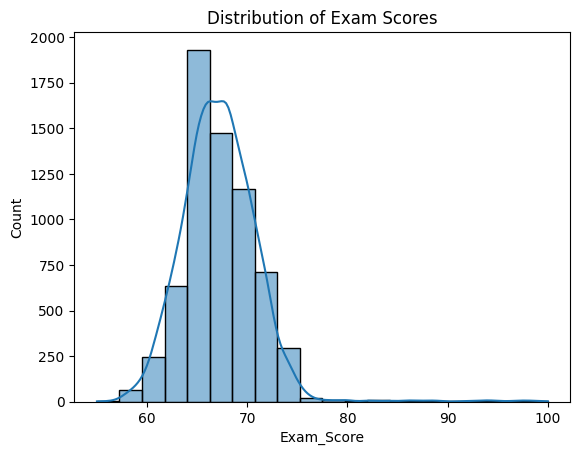

In [18]:
sns.histplot(df['Exam_Score'], kde=True, bins=20)
plt.title('Distribution of Exam Scores')
plt.show()

### 🔗 Correlation Among Numerical Features

Next, we examine the relationships between numerical features using a **correlation matrix**.

- The heatmap shows how strongly each feature is linearly related to the others, with values ranging from -1 to 1.  
- Features with higher correlation to the target (**Exam_Score**) are more likely to influence performance.  
- In this dataset, **Hours_Studied** (≈0.45) and **Attendance** (≈0.58) show the strongest positive correlation with exam scores.  
- Identifying these relationships helps guide feature selection and engineering for predictive modeling.

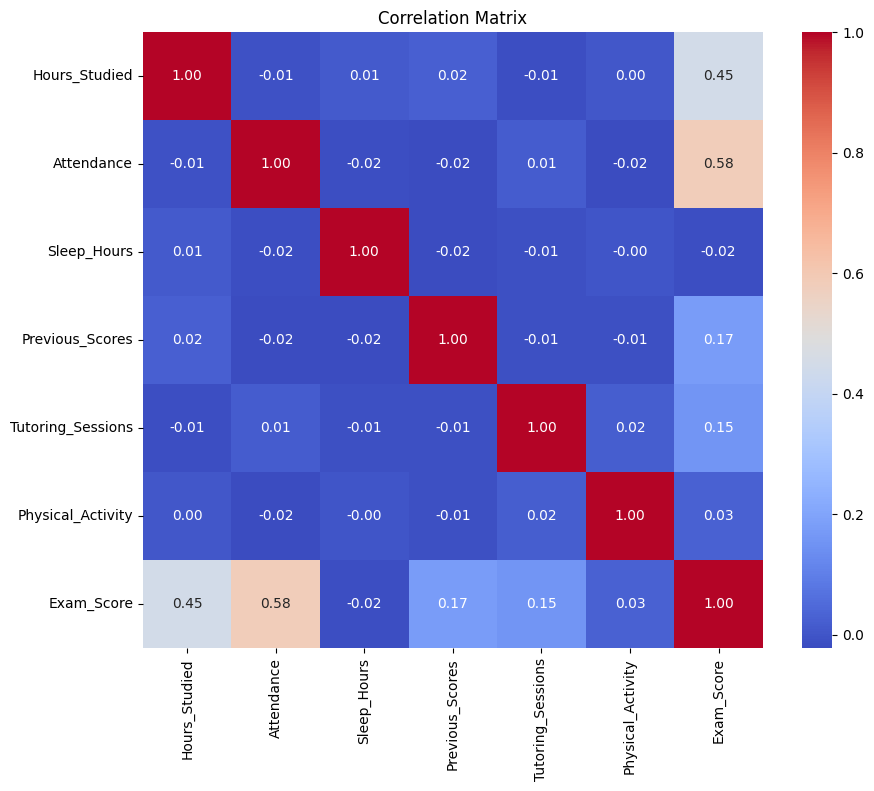

In [19]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

### 📊 Numerical Features vs Exam Score

To understand how numerical features influence exam performance, we use **regression plots** to visualize the relationship between each feature and **Exam_Score**.

- **Hours_Studied**: Shows a clear positive trend, indicating that students who study more tend to achieve higher scores.  
- **Attendance**: Also shows a moderate positive relationship, suggesting that consistent class attendance helps improve performance.  
- **Previous_Scores**: Displays a weaker trend, implying that past performance alone may not strongly predict current exam scores.  

These visualizations complement the correlation analysis and help us see both the **strength** and **direction** of relationships between numerical features and the target.

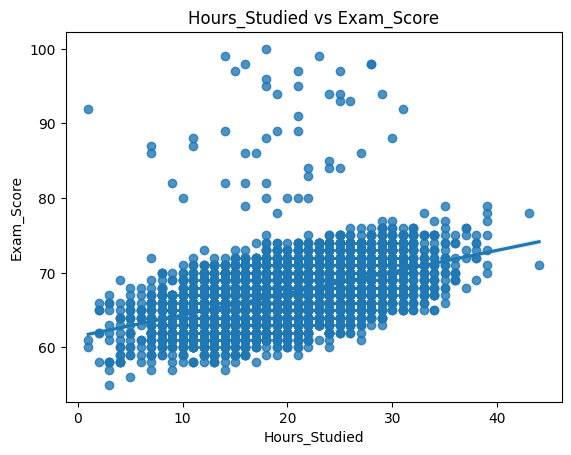

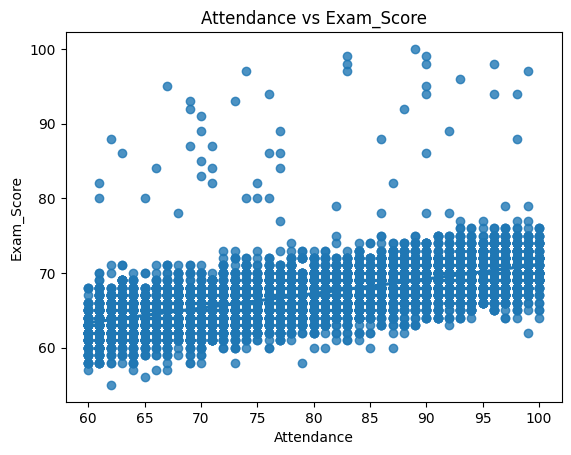

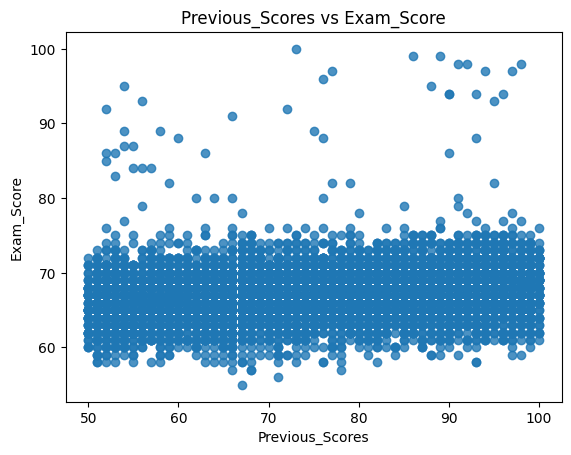

In [25]:
cols1 = ['Hours_Studied', 'Attendance', 'Previous_Scores']

for col in cols1:
    if col != 'Exam_Score':
        sns.regplot(x=df[col], y=df['Exam_Score'])
        plt.title(f'{col} vs Exam_Score')
        plt.show()

### 📦 Categorical & Other Features vs Exam Score

Next, we explore how categorical and discrete features relate to **Exam_Score** using **boxplots**.  

- Boxplots allow us to compare distributions of exam scores across different categories or discrete ranges.  
- The selected features include both **numerical discrete features** (like Sleep_Hours, Tutoring_Sessions, Physical_Activity) and **true categorical features** from the dataset.  
- Each plot shows the spread of exam scores within each category, helping identify:  
  - Which categories are associated with higher or lower scores.  
  - Potential outliers or unusual patterns in the data.  
- Using **2 plots per row** keeps the visualizations organized and easy to interpret.

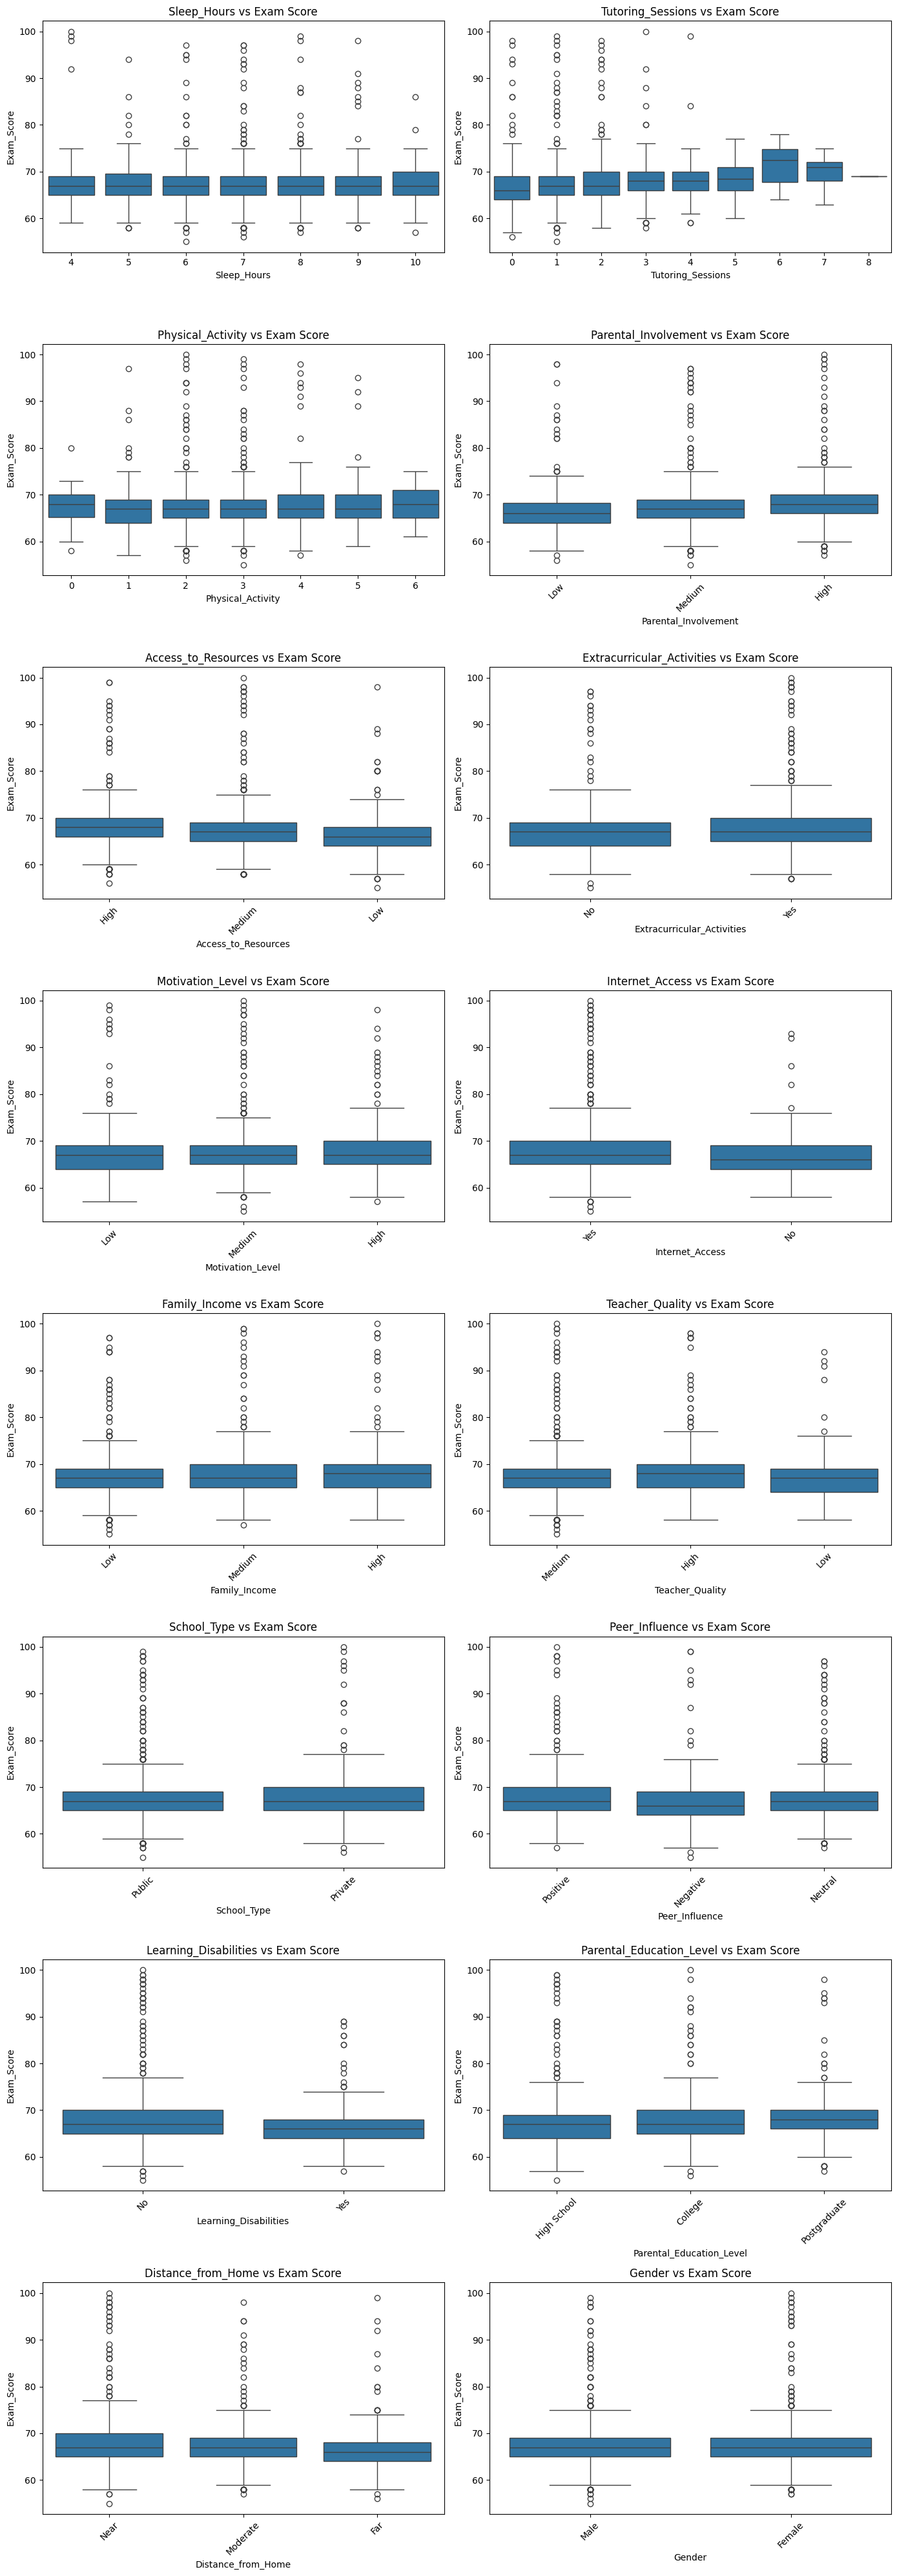

In [ ]:
import math

cols = ['Sleep_Hours', 'Tutoring_Sessions', 'Physical_Activity'] + df.select_dtypes(include='object').columns.tolist()
n = len(cols)
rows = math.ceil(n / 2)

fig, axes = plt.subplots(rows, 2, figsize=(14, 5*rows))

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]  
    sns.boxplot(x=col, y='Exam_Score', data=df, ax=ax)
    ax.set_title(f'{col} vs Exam Score')
    
    if df[col].dtype == 'object':
        plt.setp(ax.get_xticklabels(), rotation=45)

if n % 2 != 0:
    fig.delaxes(axes[-1, -1])

plt.tight_layout()
plt.show()

### 🔢 Converting Categorical Features to Numeric

To prepare the dataset for analysis and modeling, we convert categorical and ordinal features into numerical values.  

- **Binary features** (e.g., `Yes/No`, `Negative/Positive`) are mapped to `0/1` or `0/1/2` to represent their categories numerically.  
- **Ordinal features** (e.g., `Low/Medium/High`, `High School/College/Postgraduate`) are mapped to increasing integers (`1-2-3`) to preserve the order of levels.  
- This transformation allows us to:  
  - Compute correlations between features and the target.  
  - Use the data in regression and tree-based models.  

> **Note:** Mapping ordinal features assumes a linear relationship between categories. For models sensitive to spacing (like linear regression), this should be considered. For tree-based models, this mapping works naturally.

In [29]:
df['Parental_Involvement'] = df['Parental_Involvement'].map({'Low': 1, 'Medium': 2, 'High': 3})
df['Access_to_Resources'] = df['Access_to_Resources'].map({'Low': 1, 'Medium': 2, 'High': 3})
df['Extracurricular_Activities'] = df['Extracurricular_Activities'].map({'No' : 0, 'Yes' : 1})
df['Motivation_Level'] = df['Motivation_Level'].map({'Low': 1, 'Medium': 2, 'High': 3})
df['Internet_Access'] = df['Internet_Access'].map({'No' : 0, 'Yes' : 1})
df['Family_Income'] = df['Family_Income'].map({'Low': 1, 'Medium': 2, 'High': 3})
df['Teacher_Quality'] = df['Teacher_Quality'].map({'Low': 1, 'Medium': 2, 'High': 3})
df['School_Type'] = df['School_Type'].map({'Public': 1, 'Private': 2})
df['Peer_Influence'] = df['Peer_Influence'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})
df['Learning_Disabilities'] = df['Learning_Disabilities'].map({'No' : 0, 'Yes' : 1})
df['Parental_Education_Level'] = df['Parental_Education_Level'].map({'High School': 1, 'College': 2, 'Postgraduate': 3})
df['Distance_from_Home'] = df['Distance_from_Home'].map({'Near': 1,'Moderate': 2 ,'Far': 3})
df['Gender'] = df['Gender'].map({'Female':  0 , 'Male' : 1})

### 🧩 Preparing Data for Modeling

Before building predictive models, we split the dataset into **features (X)** and the **target variable (y)**:

- `X` contains all features except the target (`Exam_Score`).  
- `y` contains the target variable we want to predict.  

We then split the data into **training and testing sets**:

- **Training set**: 80% of the data, used to train the model.  
- **Testing set**: 20% of the data, used to evaluate model performance.  
- `random_state=42` ensures reproducibility of the split.

> This setup allows us to train models on known data and fairly assess their ability to predict unseen data.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [35]:
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')


Mean Squared Error: 2.30
R-squared: 0.83


### 📌 Linear Regression Feature Importance

The coefficients of the linear regression model show how each feature impacts **Exam_Score**:

- **Positive coefficients** indicate that increasing the feature value tends to **increase exam scores**.  
- **Negative coefficients** indicate that increasing the feature value tends to **decrease exam scores**.  

**Top influential features (positive impact):**  
- `Access_to_Resources`, `Parental_Involvement`, `Internet_Access`  

**Features with moderate positive impact:**  
- `Extracurricular_Activities`, `Motivation_Level`, `Teacher_Quality`, `Parental_Education_Level`, `Family_Income`, `Peer_Influence`, `Tutoring_Sessions`  

**Negative impact features:**  
- `Learning_Disabilities`, `Distance_from_Home`  

**Minimal impact features:**  
- `Hours_Studied`, `Attendance`, `Physical_Activity`, `Previous_Scores`, `Gender`, `School_Type`, `Sleep_Hours`  

> **Insight:** While traditional factors like study hours and attendance do matter, **social and family support features have the strongest impact on exam performance**, highlighting their crucial role in student success.

In [ ]:
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)
coef_table

,Feature,Coefficient
3,Access_to_Resources,1.046299
2,Parental_Involvement,1.015806
8,Internet_Access,0.947342
15,Learning_Disabilities,-0.885075
4,Extracurricular_Activities,0.550159
7,Motivation_Level,0.540205
11,Teacher_Quality,0.527615
16,Parental_Education_Level,0.506523
10,Family_Income,0.500668
13,Peer_Influence,0.494354


### 🌳 Random Forest Regression

In addition to Linear Regression, we apply a **Random Forest Regressor** to predict **Exam_Score**:

- **Random Forest** is an ensemble of decision trees that can capture **non-linear relationships** and **feature interactions** automatically.  
- Unlike Linear Regression, it does not assume a linear relationship between features and the target.  
- This model is useful to see if more complex patterns in the data can improve prediction accuracy.  

We will:
1. Train the model on the **training set**.  
2. Predict exam scores on the **testing set**.  
3. Evaluate the model using **Mean Squared Error (MSE)** and **R-squared (R²)** metrics.

In [41]:
from sklearn.ensemble import RandomForestRegressor
model2 = RandomForestRegressor(n_estimators=500, random_state=42 , min_samples_leaf=5)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)
print(f'Random Forest Mean Squared Error: {mse2:.2f}')
print(f'Random Forest R-squared: {r2_2:.2f}')

Random Forest Mean Squared Error: 3.58
Random Forest R-squared: 0.73


- **Performance**:  
- Maximum R² achieved: 0.73  
- Mean Squared Error (MSE) improved slightly from the untuned model.  

**Observations**:  
- Even after tuning, Random Forest did not outperform Linear Regression (R² = 0.83).  
- This suggests that the dataset has **strong linear relationships**, which Linear Regression captures efficiently.  
- However, Random Forest still provides **feature importance insights** and can handle potential non-linearities.  

> Hyperparameter tuning is important for tree-based models to prevent overfitting and improve generalization, even if the final R² does not surpass a simple linear model.

In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 500}


### ⚡ XGBoost Regression

To explore a more advanced ensemble method, we apply **XGBoost Regressor**:

- **XGBoost** (Extreme Gradient Boosting) is a powerful gradient boosting algorithm that builds trees sequentially, where each tree **corrects the errors of the previous trees**.  
- It is effective for **tabular data**, especially when there are **non-linear relationships or interactions** between features.  
- Unlike Random Forest, which builds trees independently, XGBoost is **boosted**, so it can capture more complex patterns.  

We will:
1. Train the model on the **training set**.  
2. Predict exam scores on the **testing set**.  
3. Evaluate using **Mean Squared Error (MSE)** and **R-squared (R²)** metrics.  

> After training, we can compare XGBoost with Linear Regression and Random Forest to determine the best predictive model for **Exam_Score**.

In [42]:
from xgboost import XGBRegressor
model3 = XGBRegressor(n_estimators=100, random_state=42)
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)
mse3 = mean_squared_error(y_test, y_pred3)
r2_3 = r2_score(y_test, y_pred3)
print(f'XGBoost Mean Squared Error: {mse3:.2f}')
print(f'XGBoost R-squared: {r2_3:.2f}')


XGBoost Mean Squared Error: 3.80
XGBoost R-squared: 0.71


### 🔗 ElasticNet Regression

We also apply **ElasticNet**, a **regularized linear regression model**:

- **ElasticNet** combines:
  - **L1 penalty (Lasso)** → encourages sparsity (some coefficients can become 0).  
  - **L2 penalty (Ridge)** → shrinks coefficients to prevent overfitting.  
- This is useful when features are **correlated** or we want a model that is **robust to multicollinearity**.  
- Hyperparameters:
  - `alpha=0.5` → overall strength of regularization.  
  - `l1_ratio=0.05` → mostly L2 (ridge-like) regularization with a small L1 component.

**Steps:**
1. Train ElasticNet on the **training set**.  
2. Predict `Exam_Score` on the **testing set**.  
3. Evaluate using **Mean Squared Error (MSE)** and **R-squared (R²)** metrics.

Example output:  

In [ ]:
from sklearn.linear_model import ElasticNet
model4 = ElasticNet(alpha=0.5, l1_ratio=0.05, random_state=42)
model4.fit(X_train, y_train)
y_pred4 = model4.predict(X_test)
mse4 = mean_squared_error(y_test, y_pred4)
r2_4 = r2_score(y_test, y_pred4)
print(f'ElasticNet Mean Squared Error: {mse4:.2f}')
print(f'ElasticNet R-squared: {r2_4:.2f}')


ElasticNet Mean Squared Error: 2.93
ElasticNet R-squared: 0.78


### 🏔️ Ridge Regression

We also apply **Ridge Regression**, a **regularized linear model** that uses an **L2 penalty**:

- **L2 penalty** shrinks the coefficients towards zero to prevent overfitting, but unlike Lasso, it does **not set coefficients exactly to zero**.  
- Ridge is particularly useful when features are **correlated** or the model might overfit.  
- Hyperparameter:
  - `alpha=1.0` → strength of regularization (higher → more shrinkage).

**Steps:**
1. Train Ridge Regression on the **training set**.  
2. Predict `Exam_Score` on the **testing set**.  
3. Evaluate using **R-squared (R²)**.

Example output:  

In [43]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("Ridge R²:", ridge.score(X_test, y_test))


Ridge R²: 0.8257938785971872


## 📊 Model Comparison: Exam Score Prediction

We trained several models to predict **Exam_Score** and compared their performance using **R-squared (R²)**.

| Model | R² | Observations |
|-------|----|--------------|
| **Linear Regression** | 0.83 | Best performance; captures the **dominant linear relationships** in the dataset. |
| **Ridge Regression** | 0.83 | L2-regularized linear model; similar to Linear Regression because features are already well-behaved. |
| **ElasticNet** | 0.78 | Combines L1 and L2 penalties; slight reduction in R² due to regularization shrinking coefficients. |
| **Random Forest** | 0.73 | Captures non-linearities, but dataset is mostly linear → model cannot outperform Linear Regression. |
| **Random Forest (tuned)** | 0.73 | Hyperparameter tuning stabilizes the model but does **not increase R²** significantly. |
| **XGBoost** | 0.70 | Gradient boosting; overfits slightly and cannot capture more signal than the linear relationships already modeled. |

---

### 🔹 Key Insights

1. **Linear relationships dominate**  
   - Features like `Hours_Studied`, `Attendance`, and `Previous_Scores` have strong linear effects.  
   - Linear models capture these effectively, explaining the higher R².

2. **Tree-based models underperform**  
   - Random Forest and XGBoost attempt to model non-linear patterns that **aren’t prominent** in this dataset.  
   - Small gains from hyperparameter tuning are limited due to linearity.

3. **Regularized linear models**  
   - Ridge and ElasticNet prevent overfitting, but for this clean dataset, regularization **does not improve R²**.  
   - ElasticNet’s slightly lower R² is due to L1 penalty shrinking some coefficients.

4. **Feature scaling**  
   - Scaling (StandardScaler) does **not affect Linear Regression R²**, only changes coefficient magnitudes.  

---

> ✅ **Conclusion:**  
> For this dataset, **simple Linear Regression** is the most effective and interpretable model.  
> Tree-based and regularized models provide additional insights (feature importance, coefficient stability) but **do not improve predictive performance**.